In [1]:
from ravex import MultiPlanetSystem, maroonx_serval_error
import numpy as np
import astropy.units as u
import astropy.time as t
import matplotlib.pyplot as plt

In [2]:
# Define the host star mass
mass_star = 0.2 * u.solMass

# Define a single planet
planet1 = {
    "mass": 5.0 * u.earthMass,
    "time_periastron": t.Time("2025-06-21T05:48:29.000", format="isot", scale="utc"),
    "inclination": 90.0 * u.deg,
    "argument_periapse": 90.0 * u.deg,
    "eccentricity": 0.0,
    "orbital_period": 13 * u.day,
}

# Build the planetary system
system = MultiPlanetSystem(mass_star, [planet1])

In [3]:
# Build a dense and regular time grid over the same observing baseline
n_model = 10000
# Define the observing baseline
start_time = t.Time("2026-07-01T00:00:00", format="isot", scale="utc")
span_days = 100

time_grid = t.Time(
    start_time.jd + np.linspace(0, span_days, n_model),
    format="jd",
    scale="utc"
)

# Compute the noiseless RV model
jd_model, rv_model, phases_model, phased_model = system.get_rvs(time_grid)

In [4]:
rv_max = np.max(rv_model)
rv_min = np.min(rv_model)
K_est = 0.5 * (rv_max - rv_min)

print(f"Estimated semi-amplitude K: {K_est:.3f} m/s")

Estimated semi-amplitude K: 3.976 m/s


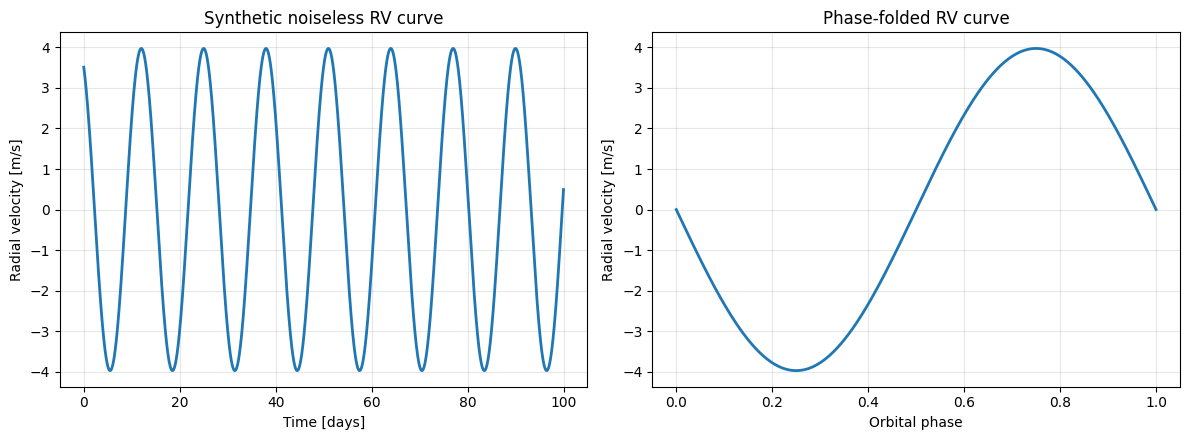

In [5]:
# Plot the theoretical noiseless RV curve in time and phase
time_days = jd_model - jd_model[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left panel: RV as a function of time
axes[0].plot(time_days, rv_model, lw=2)
axes[0].set_xlabel("Time [days]")
axes[0].set_ylabel("Radial velocity [m/s]")
axes[0].set_title("Synthetic noiseless RV curve")
axes[0].grid(alpha=0.3)

# Right panel: RV as a function of orbital phase
axes[1].plot(phased_model["p0"]["phase"], phased_model["p0"]["rv"], lw=2)
axes[1].set_xlabel("Orbital phase")
axes[1].set_ylabel("Radial velocity [m/s]")
axes[1].set_title("Phase-folded RV curve")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
# MAROON-X input from the ETC
snr_peak_red = 77   # example value from the ETC
snr_peak_blue = 24.5   # in this example the blue contribution is very low

arm1 = "red"
arm2 = "blue"

# Estimated intrinsic SERVAL RV uncertainty for MAROON-X
sigma_maroonx_red = maroonx_serval_error(
    snr_peak=snr_peak_red,
    spectral_type="M4.5",  
    arm=arm1
)

sigma_maroonx_blue = maroonx_serval_error(
    snr_peak=snr_peak_blue,
    spectral_type="M4.5",   
    arm=arm2
)

# Assumed stellar jitter. For M quiet stars, the jitter is in the range of 2-3m/s (Ruh et al. 2024)
sigma_jitter = 2.5  # m/s

# Total per-measurement uncertainty
sigma_eff_maroonx_red = np.sqrt(sigma_maroonx_red**2 + sigma_jitter**2)
sigma_eff_maroonx_blue = np.sqrt(sigma_maroonx_blue**2 + sigma_jitter**2)


print(f"MAROON-X ({arm1} arm) instrumental error: {sigma_maroonx_red:.3f} m/s")
print(f"Assumed stellar jitter: {sigma_jitter:.3f} m/s")
print(f"Total RV uncertainty per measurement: {sigma_eff_maroonx_red:.3f} m/s")
print("**********")
print(f"MAROON-X ({arm2} arm) instrumental error: {sigma_maroonx_blue:.3f} m/s")
print(f"Assumed stellar jitter: {sigma_jitter:.3f} m/s")
print(f"Total RV uncertainty per measurement: {sigma_eff_maroonx_blue:.3f} m/s")

MAROON-X (red arm) instrumental error: 1.693 m/s
Assumed stellar jitter: 2.500 m/s
Total RV uncertainty per measurement: 3.019 m/s
**********
MAROON-X (blue arm) instrumental error: 3.716 m/s
Assumed stellar jitter: 2.500 m/s
Total RV uncertainty per measurement: 4.479 m/s


In [7]:
# Simulate discrete RV observations with noise
n_obs = 30
start_time = t.Time("2026-07-01T00:00:00", format="isot", scale="utc")

rng = np.random.default_rng(42)

observation_dates = system.obs_dates(
    n_obs=n_obs,
    span_days=span_days,
    date_one=start_time,
    rng=rng
)

jd_sim_red, rv_sim_red, phases_sim_red, phased_sim_red = system.get_rvs(
    observation_dates,
    noise=sigma_eff_maroonx_red * u.m / u.s,
    rng=np.random.default_rng(42)
)

jd_sim_blue, rv_sim_blue, phases_sim_blue, phased_sim_blue = system.get_rvs(
    observation_dates,
    noise=sigma_eff_maroonx_blue * u.m / u.s,
    rng=np.random.default_rng(43)
)

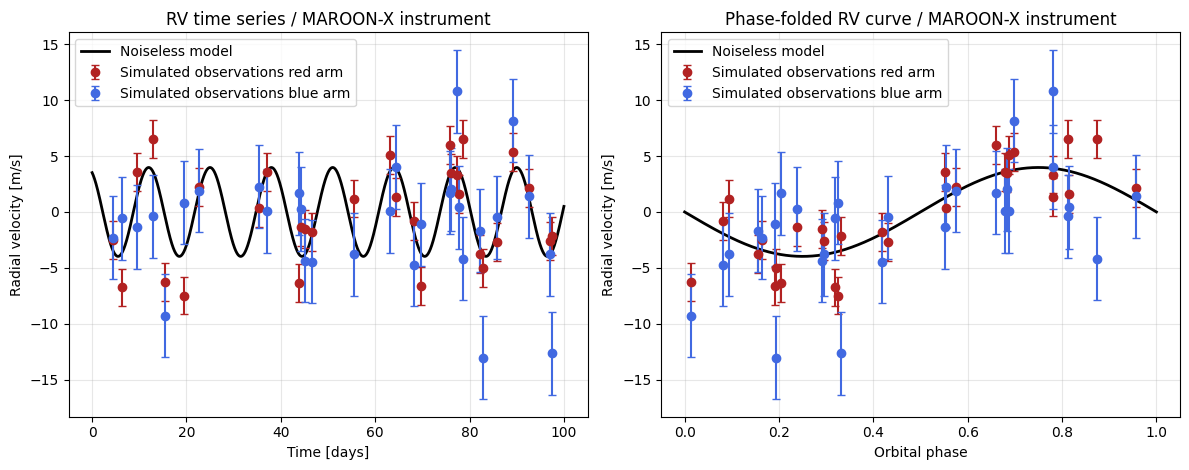

In [8]:
# Plot the noiseless model and the simulated RV observations in time and phase
time_model_days = jd_model - jd_model[0]
time_sim_days_red = jd_sim_red - jd_model[0]
time_sim_days_blue = jd_sim_blue - jd_model[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Left panel: time series
axes[0].plot(time_model_days, rv_model, lw=2, color='black',label="Noiseless model")
axes[0].errorbar(
    time_sim_days_red,
    rv_sim_red,
    yerr=sigma_maroonx_red,
    fmt="o",
    capsize=3,
    color="firebrick",
    label="Simulated observations red arm"
)

axes[0].errorbar(
    time_sim_days_blue,
    rv_sim_blue,
    yerr=sigma_maroonx_blue,
    fmt="o",
    capsize=3,
    color="royalblue",
    label="Simulated observations blue arm"
)

axes[0].set_xlabel("Time [days]")
axes[0].set_ylabel("Radial velocity [m/s]")
axes[0].set_title("RV time series / MAROON-X instrument")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right panel: phase-folded curve
axes[1].plot(phased_model["p0"]["phase"], phased_model["p0"]["rv"], lw=2, color='black',label="Noiseless model")

axes[1].errorbar(
    phased_sim_red["p0"]["phase"],
    phased_sim_red["p0"]["rv"],
    yerr=sigma_maroonx_red,
    fmt="o",
    capsize=3,
    color="firebrick",
    label="Simulated observations red arm"
)

axes[1].errorbar(
    phased_sim_blue["p0"]["phase"],
    phased_sim_blue["p0"]["rv"],
    yerr=sigma_maroonx_blue,
    fmt="o",
    capsize=3,
    color="royalblue",
    label="Simulated observations blue arm"
)

axes[1].set_xlabel("Orbital phase")
axes[1].set_ylabel("Radial velocity [m/s]")
axes[1].set_title("Phase-folded RV curve / MAROON-X instrument")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Detection significance as a function of the number of observations

In this section we use `detectability_tracker` to evaluate how the detection performance evolves as the number of RV observations increases.

For each value of `N` in `n_obs_list`, the function generates many synthetic observing campaigns (`n_iter`) over the same time span, computes a generalized Lomb–Scargle periodogram, and checks whether the injected planetary signal is successfully recovered.

A trial is considered a successful detection when:

1. the strongest recovered period is close enough to the injected one, within a relative tolerance `tol_rel`, and  
2. the recovered signal reaches the required significance threshold, set here to `3σ` through `sigma_target=3.0`.

The main quantity of interest is `N_min_90`, i.e. the minimum number of observations required to recover the planet with at least 90% probability under the adopted assumptions.

Here we compare the MAROON-X red and blue arms separately.

In [10]:
# Grid of observation numbers to explore
n_obs_list = np.arange(6, 101, 2)

# --- RED arm ---
# For each N in n_obs_list, detectability_tracker simulates many synthetic
# RV campaigns, computes a GLS periodogram, and estimates the fraction of
# successful detections above the requested significance threshold.
res_det_red_3s = system.detectability_tracker(
    planet_index=0,
    n_obs_list=n_obs_list,
    span_days=span_days,
    start_time=start_time,
    sigma_eff=sigma_eff_maroonx_red * u.m / u.s,
    n_iter=400,
    tol_rel=0.10,
    sigma_target=3.0,
    fap_method="baluev",
    rng_seed=42
)

# --- BLUE arm ---
# Same analysis, but using the effective RV uncertainty of the blue arm.
res_det_blue_3s = system.detectability_tracker(
    planet_index=0,
    n_obs_list=n_obs_list,
    span_days=span_days,
    start_time=start_time,
    sigma_eff=sigma_eff_maroonx_blue * u.m / u.s,
    n_iter=400,
    tol_rel=0.10,
    sigma_target=3.0,
    fap_method="baluev",
    rng_seed=43
)

print("RED arm")
print("N_min_90 at 3σ:", res_det_red_3s["N_min_90"])
print()

print("BLUE arm")
print("N_min_90 at 3σ:", res_det_blue_3s["N_min_90"])

RED arm
N_min_90 at 3σ: 64

BLUE arm
N_min_90 at 3σ: nan


### Interpretation

In this example, the planet is robustly detectable with the **MAROON-X red arm**, reaching a 90% recovery probability above the adopted `3σ` threshold with **64 observations**.

For the **blue arm**, `N_min_90` returns `NaN`, meaning that the 90% detection probability threshold is not reached within the tested range of observation numbers.

Under the assumptions adopted here, this suggests that the planetary signal is less favorably recovered in the blue arm when considered on its own, likely because the signal-to-noise ratio is not sufficient to secure a robust standalone detection over the explored observing campaign.

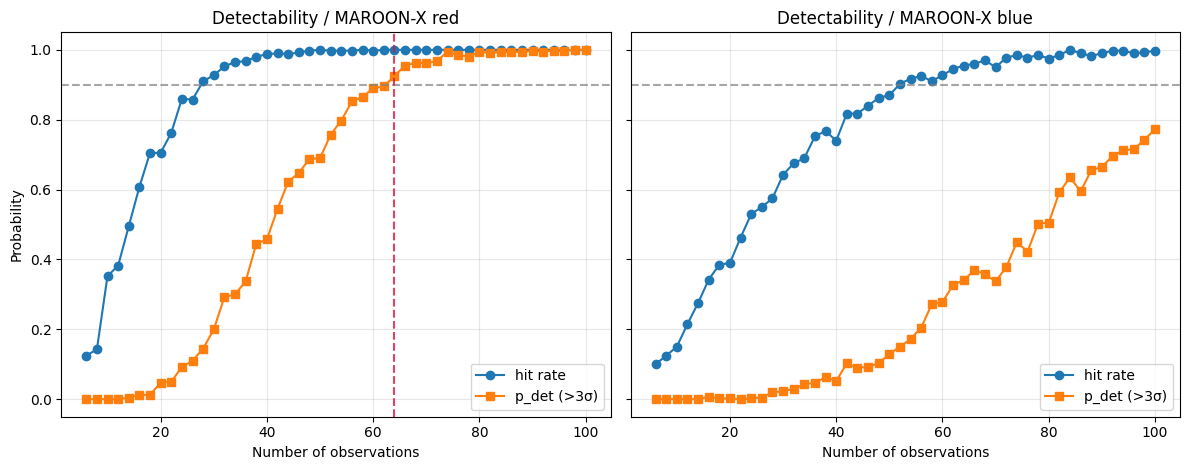

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

# RED
axes[0].plot(res_det_red_3s["n_obs"], res_det_red_3s["p_hit"], "o-", label="hit rate")
axes[0].plot(res_det_red_3s["n_obs"], res_det_red_3s["p_det"], "s-", label="p_det (>3σ)")
axes[0].axhline(0.9, ls="--", color="gray", alpha=0.7)
if np.isfinite(res_det_red_3s["N_min_90"]):
    axes[0].axvline(res_det_red_3s["N_min_90"], ls="--", color="crimson", alpha=0.8)
axes[0].set_title("Detectability / MAROON-X red")
axes[0].set_xlabel("Number of observations")
axes[0].set_ylabel("Probability")
axes[0].grid(alpha=0.3)
axes[0].legend()

# BLUE
axes[1].plot(res_det_blue_3s["n_obs"], res_det_blue_3s["p_hit"], "o-", label="hit rate")
axes[1].plot(res_det_blue_3s["n_obs"], res_det_blue_3s["p_det"], "s-", label="p_det (>3σ)")
axes[1].axhline(0.9, ls="--", color="gray", alpha=0.7)
if np.isfinite(res_det_blue_3s["N_min_90"]):
    axes[1].axvline(res_det_blue_3s["N_min_90"], ls="--", color="crimson", alpha=0.8)
axes[1].set_title("Detectability / MAROON-X blue")
axes[1].set_xlabel("Number of observations")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation of the main outputs

- `hit rate`: fraction of trials in which the strongest recovered period falls within the adopted relative tolerance around the injected period. In this example, we use `tol_rel = 0.10`, meaning that the recovered period must lie within **10%** of the injected one.
- `p_det`: fraction of trials in which the period is correctly recovered **and** the signal also exceeds the required detection-significance threshold.
- `N_min_90`: first value of `N` for which `p_det >= 0.90`.

In practice, `N_min_90` provides a convenient estimate of the minimum observational effort needed to secure a detection at a user-defined sigma.

In [12]:
# Let's now repeat the same but with a stronger detection requirement (at 5sigma)
n_obs_list = np.arange(6, 101, 2)

# --- RED arm ---
res_det_red_5s = system.detectability_tracker(
    planet_index=0,
    n_obs_list=n_obs_list,
    span_days=span_days,
    start_time=start_time,
    sigma_eff=sigma_eff_maroonx_red * u.m/u.s,
    n_iter=400,
    tol_rel=0.10,
    sigma_target=5.0, #here we indicate the sigma
    fap_method="baluev",
    rng_seed=42
)

# --- BLUE arm ---
res_det_blue_5s = system.detectability_tracker(
    planet_index=0,
    n_obs_list=n_obs_list,
    span_days=span_days,
    start_time=start_time,
    sigma_eff=sigma_eff_maroonx_blue * u.m/u.s,
    n_iter=400,
    tol_rel=0.10,
    sigma_target=5.0, #here we indicate the sigma
    fap_method="baluev",
    rng_seed=43
)

print("RED arm")
print("N_min_90 at 5σ:", res_det_red_5s["N_min_90"])
print()

print("BLUE arm")
print("N_min_90 at 5σ:", res_det_blue_5s["N_min_90"])

RED arm
N_min_90 at 5σ: 96

BLUE arm
N_min_90 at 5σ: nan


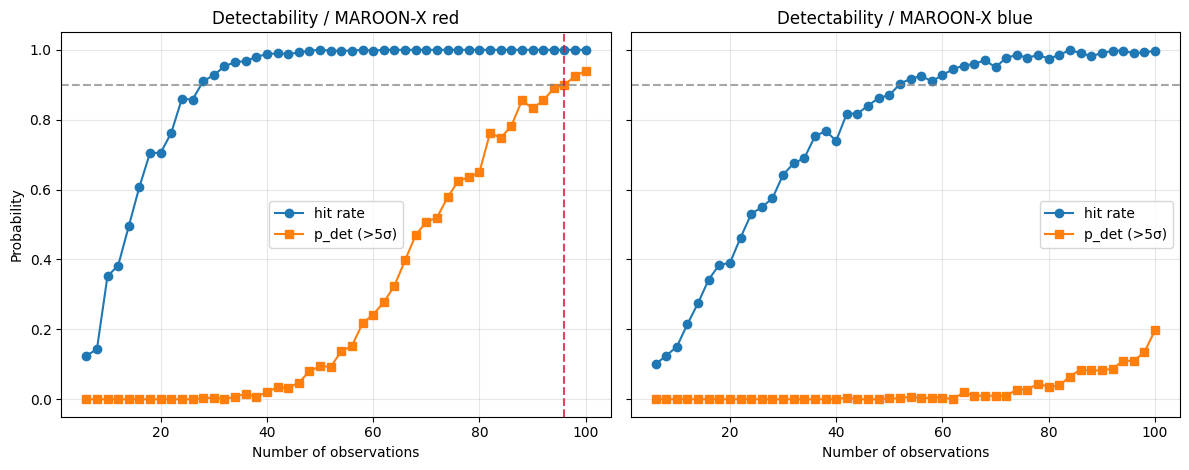

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

# RED
axes[0].plot(res_det_red_5s["n_obs"], res_det_red_5s["p_hit"], "o-", label="hit rate")
axes[0].plot(res_det_red_5s["n_obs"], res_det_red_5s["p_det"], "s-", label="p_det (>5σ)")
axes[0].axhline(0.9, ls="--", color="gray", alpha=0.7)
if np.isfinite(res_det_red_5s["N_min_90"]):
    axes[0].axvline(res_det_red_5s["N_min_90"], ls="--", color="crimson", alpha=0.8)
axes[0].set_title("Detectability / MAROON-X red")
axes[0].set_xlabel("Number of observations")
axes[0].set_ylabel("Probability")
axes[0].grid(alpha=0.3)
axes[0].legend()

# BLUE
axes[1].plot(res_det_blue_5s["n_obs"], res_det_blue_5s["p_hit"], "o-", label="hit rate")
axes[1].plot(res_det_blue_5s["n_obs"], res_det_blue_5s["p_det"], "s-", label="p_det (>5σ)")
axes[1].axhline(0.9, ls="--", color="gray", alpha=0.7)
if np.isfinite(res_det_blue_5s["N_min_90"]):
    axes[1].axvline(res_det_blue_5s["N_min_90"], ls="--", color="crimson", alpha=0.8)
axes[1].set_title("Detectability / MAROON-X blue")
axes[1].set_xlabel("Number of observations")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Comparison between the 3σ and 5σ detection criteria

As expected, adopting a more stringent detection threshold increases the observational effort required to secure a robust planetary detection.

For the **MAROON-X red arm**, the minimum number of observations needed to reach a 90% detection probability increases from **64 observations at 3σ** to **96 observations at 5σ**. This reflects the fact that a higher-significance detection requires the planetary signal to stand out more clearly above the noise and periodogram false-alarm background.

For the **blue arm**, `N_min_90` remains `NaN` at both significance levels, indicating that the adopted observing campaigns are not sufficient to achieve a robust standalone detection in that arm within the explored range of observation numbers. The situation becomes even more restrictive at 5σ, as expected.

Overall, this comparison illustrates a general and important point: **the higher the required detection significance, the larger the number of RV observations needed to securely recover the planet**.